# For playing around with plotting and data parameters in analyze_friction.py

In [2]:
import argparse
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
import yaml

In [6]:
# ---------------------------------------------------------------------------
# Input data you want to analyze here as the date
# ---------------------------------------------------------------------------
# _SCRIPT_DIR = "/Users/jazlabamini/Documents/nikashap/orcaSDK_tutorials/tests/"
_SCRIPT_DIR = "/Users/Nikasha/Documents/GitHub/orcaSDK_tutorials/tests/"

EXP_DATE = "26_04_21-14_25_29"

# ---------------------------------------------------------------------------
# Resolve experiment directory and load the saved YAML snapshot
# ---------------------------------------------------------------------------
# Base data dir is relative to script; the date subfolder identifies the experiment
_BASE_DATA_DIR = os.path.normpath(os.path.join(_SCRIPT_DIR, "../data"))
EXPERIMENT_DIR = os.path.join(_BASE_DATA_DIR, EXP_DATE)

_PARAMS_PATH = os.path.join(EXPERIMENT_DIR, "calibration_params.yaml")
if not os.path.exists(_PARAMS_PATH):
    print(f"ERROR: No calibration_params.yaml found in {EXPERIMENT_DIR}")
    print("Make sure you collected data with collect_calibration_data.py first.")
    sys.exit(1)

with open(_PARAMS_PATH, "r") as f:
    PARAMS = yaml.safe_load(f)

M_SHAFT_KG = PARAMS["mass_shaft_kg"]
G_MMPSS = 9810.0  # gravitational acceleration in mm/s²
WEIGHT_MN = M_SHAFT_KG * G_MMPSS  # normal force in mN

VELOCITY_ESTIMATOR = PARAMS.get("velocity_estimator", "SG").upper()
SAVGOL_WINDOW = PARAMS["savgol_window"]
SAVGOL_ORDER = PARAMS["savgol_order"]
RW_WINDOW = PARAMS.get("rw_window", 5)
T_IGNORE_S = PARAMS["t_ignore_s"]
F_STATIC_LOW_MN = PARAMS["static_friction_low_mN"]
F_STATIC_HIGH_MN = PARAMS["static_friction_high_mN"]
STREAM_FORCE_SHIFT = PARAMS.get("stream_force_shift", 0)
USB_CHIP = PARAMS.get("usb_chip", "unknown")

## Functions

In [4]:
def load_master_data(filepath):
    """Load a master .npz file and split into per-trial dicts.

    Handles both constant-force data (calibration_dynamic_friction.npz) and
    ramp-down data (calibration_rampdown_friction.npz).  In both cases,
    force_commanded_mN is returned as a per-sample array.  A scalar
    force_label_mN is also included for grouping / plotting:
      - constant-force trials: the commanded force level
      - ramp-down trials: the target (post-switch) force
    """
    data = np.load(filepath, allow_pickle=True)

    n_trials = int(data["n_trials"])
    boundaries = data["trial_boundaries"]

    # Determine procedure type: explicit tag in new data, fallback for old data
    if "procedure_type" in data:
        procedure_type = str(data["procedure_type"])
    else:
        procedure_type = "constant"

    is_rampdown = (procedure_type == "rampdown")

    t_stream_all = data["t_stream"]
    position_um_all = data["position_um"]
    force_mN_all = data["force_mN"]
    t_accel_all = data["t_accel"]
    accel_mmpss_all = data["accel_mmpss"]

    if is_rampdown:
        force_cmd_all = data["force_commanded_mN"]
        trial_labels = data["trial_target_force_mN"]
        trial_switch_indices = data["trial_switch_index"]
    else:
        force_cmd_all = (data["force_commanded_mN"] if "force_commanded_mN" in data
                         else None)
        force_cmd_per_trial = data["trial_force_commanded_mN"]

    trials = {}
    for i in range(n_trials):
        lo, hi = boundaries[i], boundaries[i + 1]

        if is_rampdown:
            switch_idx = int(trial_switch_indices[i])
            if switch_idx < 0:
                continue
            # Deleted filtering out initial push from here
            force_cmd = force_cmd_all[lo:hi].astype(np.float64)
            label = int(trial_labels[i])
        elif force_cmd_all is not None:
            force_cmd = force_cmd_all[lo:hi].astype(np.float64)
            label = int(force_cmd_per_trial[i])
        else:
            force_cmd = np.full(hi - lo, force_cmd_per_trial[i], dtype=np.float64)
            label = int(force_cmd_per_trial[i])

        t_stream = t_stream_all[lo:hi]
        if len(t_stream) == 0:
            continue
        t0 = t_stream[0]

        trials[i + 1] = {
            "trial_num": i + 1,
            "force_commanded_mN": force_cmd,
            "force_label_mN": label,
            "t_stream_s": t_stream - t0,
            "t_accel_s": t_accel_all[lo:hi] - t0,
            "position_um": position_um_all[lo:hi].astype(np.float64),
            "force_mN": force_mN_all[lo:hi].astype(np.float64),
            "accel_mmpss": accel_mmpss_all[lo:hi].astype(np.float64),
        }

    if is_rampdown:
        force_levels = sorted(set(int(trial_labels[i]) for i in range(n_trials)))
    else:
        force_levels = data["force_levels_mN"].tolist()

    metadata = {
        "mass_shaft_kg": float(data["mass_shaft_kg"]),
        "motor_min_um": int(data["motor_min_um"]),
        "motor_max_um": int(data["motor_max_um"]),
        "force_levels_mN": force_levels,
    }

    return trials, metadata

In [7]:
def _velocity_savgol(pos_um, t, savgol_window, savgol_order):
    """Velocity via Savitzky-Golay analytical derivative (deriv=1).
    Using delta=mean(dt) because savgol_filter assumes uniform spacing.
    """
    mean_dt = np.mean(np.diff(t))
    velocity_um_s = savgol_filter(pos_um, window_length=savgol_window,
                                  polyorder=savgol_order, deriv=1, delta=mean_dt)
    return velocity_um_s / 1000.0


def _velocity_rolling_window(pos_um, t, rw_window):
    """Velocity via rolling mean of finite differences.

    v[i] is the mean of the last ``rw_window`` finite-difference
    velocity samples: (pos[i]-pos[i-1])/dt, ..., (pos[i-k+1]-pos[i-k])/dt.
    The first ``rw_window`` samples use a growing window (all differences
    available so far) so no samples are NaN.
    """
    dt = np.diff(t)                       # (n-1,)
    v_inst = np.diff(pos_um) / dt / 1000.0  # instantaneous velocity in mm/s, (n-1,)

    n = len(pos_um)
    velocity_mm_s = np.zeros(n)
    # v_inst[i] = velocity between sample i and i+1.
    # We assign v_inst[i] as the velocity "at" sample i+1 (backward difference).
    # Sample 0 gets the first available difference.
    cumsum = np.cumsum(np.concatenate([[0.0], v_inst]))
    for i in range(n):
        if i == 0:
            velocity_mm_s[0] = v_inst[0]  # only one difference available
        else:
            lo = max(0, i - rw_window)
            velocity_mm_s[i] = (cumsum[i] - cumsum[lo]) / (i - lo)

    return velocity_mm_s


def compute_friction_for_trial(trial, velocity_estimator="SG",
                               savgol_window=15, savgol_order=2,
                               rw_window=5, shift=0, shift_kinematics=False):
    """
    For one trial, compute:
      - velocity (via the chosen estimator: SG or RW)
      - F_friction = F_sensed_shifted - m * a
      - mu_d = F_friction / (m * g) (this is signed, NOT absolute value)

    Parameters
    ----------
    velocity_estimator : str
        "SG" for Savitzky-Golay (non-causal, offline), "RW" for rolling window (causal, online).
    savgol_window, savgol_order : int
        Parameters for the SG estimator (ignored when velocity_estimator=="RW").
    rw_window : int
        Number of finite-difference samples to average for the RW estimator
        (ignored when velocity_estimator=="SG").
    shift : int
        Frame shift to align force_sensed with acceleration. The motor stream
        (position, force_sensed) lags behind the real-time acceleration read
        by ``shift`` frames. So force_sensed[i+shift] corresponds to accel[i].
        We pair force_sensed[shift:n] with accel[0:n-shift].

    After shifting, only the overlapping region is kept — all arrays are
    trimmed to the same valid range.

    Returns a dict with all original fields (trimmed) plus velocity, friction,
    mu_d, force_commanded_mN (per-sample, trimmed), and
    force_sensed_unshifted_mN (sensed force at the same timepoint as
    position/velocity — NOT shift-aligned to accel).

    """
    t = trial["t_stream_s"]
    pos_um = trial["position_um"]
    sensed_force = trial["force_mN"]
    force_commanded = trial["force_commanded_mN"]
    t_accel = trial["t_accel_s"]
    accel_raw = trial["accel_mmpss"]

    # Interpolate acceleration onto stream timestamps
    accel_interp_fn = interp1d(t_accel, accel_raw, kind="linear",
                               bounds_error=False, fill_value="extrapolate")
    accel_at_stream = accel_interp_fn(t)

    # Velocity estimation
    if velocity_estimator == "SG":
        velocity_mm_s = _velocity_savgol(pos_um, t, savgol_window, savgol_order)
    elif velocity_estimator == "RW":
        velocity_mm_s = _velocity_rolling_window(pos_um, t, rw_window)
    else:
        raise ValueError(f"Unknown velocity_estimator: {velocity_estimator!r}. "
                         f"Expected 'SG' or 'RW'.")

    n = len(t)

    # Apply frame shift to align force_sensed with acceleration.
    # Position, velocity, and force_commanded are NOT shifted — they stay at
    # the stream timepoint.  force_sensed_unshifted is also at the stream
    # timepoint (same frame as position).  force_aligned (used for friction
    # calculation) is the shifted force_sensed that corresponds to accel.
    if shift > 0:
        force_aligned = sensed_force[shift:]
        accel_aligned = accel_at_stream[:n - shift]
        t_trimmed = t[:n - shift]
        if shift_kinematics:
            print("\n---NOTE---\nPosition and Velocity are shifted according to frame_shift")
            pos_trimmed = pos_um[shift:]
            vel_trimmed = velocity_mm_s[shift:]
        else:
            pos_trimmed = pos_um[:n - shift]
            vel_trimmed = velocity_mm_s[:n - shift]
        force_cmd_trimmed = force_commanded[:n - shift]
        force_sensed_unshifted = sensed_force[:n - shift]
    elif shift < 0:
        abs_shift = abs(shift)
        force_aligned = sensed_force[:n - abs_shift]
        accel_aligned = accel_at_stream[abs_shift:]
        t_trimmed = t[abs_shift:]
        if shift_kinematics:
            print("\n---NOTE---\nPosition and Velocity are shifted according to frame_shift")
            pos_trimmed = pos_um[:n - abs_shift]
            vel_trimmed = velocity_mm_s[:n - abs_shift]
        else:
            pos_trimmed = pos_um[abs_shift:]
            vel_trimmed = velocity_mm_s[abs_shift:]
        force_cmd_trimmed = force_commanded[abs_shift:]
        force_sensed_unshifted = sensed_force[abs_shift:]
    else:
        force_aligned = sensed_force
        accel_aligned = accel_at_stream
        t_trimmed = t
        pos_trimmed = pos_um
        vel_trimmed = velocity_mm_s
        force_cmd_trimmed = force_commanded
        force_sensed_unshifted = sensed_force

    # F_friction = F_sensed_aligned - m * a  (all in mN, since kg * mm/s² = mN)
    f_friction_mN = force_aligned - M_SHAFT_KG * accel_aligned

    # Coefficient of dynamic friction
    mu_d = f_friction_mN / WEIGHT_MN

    return {
        "trial_num": trial["trial_num"],
        "force_label_mN": trial["force_label_mN"],
        "force_commanded_mN": force_cmd_trimmed,
        "t_stream_s": t_trimmed,
        "position_um": pos_trimmed,
        "force_mN": force_aligned,
        "force_sensed_unshifted_mN": force_sensed_unshifted,
        "accel_mmpss": accel_aligned,
        "accel_interp_mmpss": accel_aligned,
        "velocity_mm_s": vel_trimmed,
        "f_friction_mN": f_friction_mN,
        "mu_d": mu_d,
    }

## Plotting functions

In [8]:
def plot_position_over_time(friction_trials, force_levels):
    """Plot position vs time for each force level (one subplot per level)."""
    fig, axes = plt.subplots(len(force_levels), 1,
                             figsize=(12, 4 * len(force_levels)), sharex=False)
    if len(force_levels) == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for i, force_mN in enumerate(force_levels):
        ax = axes[i]
        recs = [r for r in friction_trials if r["force_label_mN"] == force_mN]
        for j, r in enumerate(recs):
            ax.plot(r["t_stream_s"], r["position_um"],
                    linewidth=0.8, color=colors[j % len(colors)],
                    label=f"Trial {r['trial_num']}")
        ax.set_ylabel("Position (µm)")
        ax.set_title(f"F_commanded = {force_mN} mN")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")
    plt.suptitle(f"Position over time (m={M_SHAFT_KG} kg, shift={STREAM_FORCE_SHIFT})",
                 fontsize=12, y=0.98)
    plt.tight_layout()
    return fig


def plot_force_overlay_for_trial(friction_trials, trial_num):
    """Overlay force_commanded_mN and force_mN (shift-aligned) for a single trial.

    Useful for visually determining the best frame shift: if the shift is
    correct, the aligned force should track the commanded force with minimal
    lag.
    """
    rec = None
    for r in friction_trials:
        if r["trial_num"] == trial_num:
            rec = r
            break
    if rec is None:
        print(f"Trial {trial_num} not found.")
        return None

    t = rec["t_stream_s"]
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(t, rec["force_commanded_mN"], linewidth=1.2, color="tab:blue",
            alpha=0.8, label="force_commanded_mN")
    ax.plot(t, rec["force_mN"], linewidth=1.2, color="tab:red",
            alpha=0.8, label=f"force_mN (shifted by {STREAM_FORCE_SHIFT} frames)")

    if "force_sensed_unshifted_mN" in rec:
        ax.plot(t, rec["force_sensed_unshifted_mN"], linewidth=0.8,
                color="tab:green", alpha=0.5, linestyle="--",
                label="force_sensed_unshifted_mN")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Force (mN)")
    ax.set_title(f"Trial {trial_num}  —  F_label = {rec['force_label_mN']} mN  "
                 f"(shift = {STREAM_FORCE_SHIFT} frames)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

In [9]:
def plot_velocity_over_time(friction_trials, force_levels):
    """Plot velocity vs time for each force level (one subplot per level)."""
    fig, axes = plt.subplots(len(force_levels), 1,
                             figsize=(12, 4 * len(force_levels)), sharex=False)
    if len(force_levels) == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for i, force_mN in enumerate(force_levels):
        ax = axes[i]
        recs = [r for r in friction_trials if r["force_label_mN"] == force_mN]
        for j, r in enumerate(recs):
            ax.plot(r["t_stream_s"], r["velocity_mm_s"],
                    linewidth=0.8, color=colors[j % len(colors)],
                    label=f"Trial {r['trial_num']}")
        ax.set_ylabel("Velocity (mm/s)")
        ax.set_title(f"F_commanded = {force_mN} mN")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")
    if VELOCITY_ESTIMATOR == "SG":
        vel_label = f"Savitzky-Golay window={SAVGOL_WINDOW}, order={SAVGOL_ORDER}"
    else:
        vel_label = f"Rolling window K={RW_WINDOW}"
    plt.suptitle(f"Velocity estimates ({vel_label}, m={M_SHAFT_KG} kg)",
                 fontsize=12, y=0.98)
    plt.tight_layout()
    return fig

def plot_Fsensed_over_time(friction_trials, force_levels):
    """Plot sensed outputted force over time for ecah force level (one subplot per level)."""
    fig, axes = plt.subplots(len(force_levels), 1,
                             figsize=(12, 4 * len(force_levels)), sharex=False)
    if len(force_levels) == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0,1,10))

    for i, force_mN in enumerate(force_levels): 
        ax = axes[i]
        recs = [r for r in friction_trials if r["force_label_mN"] == force_mN]
        for j, r in enumerate(recs):
            ax.plot(r["t_stream_s"], r["force_mN"],
                    linewidth=0.8, color=colors[j % len(colors)],
                    label=f"Trial {r['trial_num']}")
        ax.set_ylabel("Sensed force (mN)")
        ax.set_title(f"F_commanded = {force_mN} mN")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")
    plt.suptitle(f"Sensed force output; filter strength = ___ m={M_SHAFT_KG} kg)", fontsize=12, y=0.98)
    plt.tight_layout()
    return fig

def plot_accel_over_time(friction_trials, force_levels):
    """Plot measured acceleration over time for each force level (one subplot per level)."""
    fig, axes = plt.subplots(len(force_levels), 1,
                             figsize=(12, 4 * len(force_levels)), sharex=False)
    if len(force_levels) == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0,1,10))

    for i, force_mN in enumerate(force_levels): 
        ax = axes[i]
        recs = [r for r in friction_trials if r["force_label_mN"] == force_mN]
        for j, r in enumerate(recs):
            ax.plot(r["t_stream_s"], r["accel_mmpss"],
                    linewidth=0.8, color=colors[j % len(colors)],
                    label=f"Trial {r['trial_num']}")
        ax.set_ylabel("Acceleration (mm/s^2)")
        ax.set_title(f"F_commanded = {force_mN} mN")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")
    plt.suptitle(f"Measured acceleration; filter strength = ___ m={M_SHAFT_KG} kg)", fontsize=12, y=0.98)
    plt.tight_layout()
    return fig

def plot_stribeck_curve(friction_trials, force_levels):
    """Plot Stribeck curve: μ_d vs shaft speed v."""
    fig, ax = plt.subplots(figsize=(10, 6))

    speeds_all = []
    mu_d_all = []
    force_all = []

    for force_mN in force_levels:
        recs = [r for r in friction_trials if r["force_label_mN"] == force_mN]
        for r in recs:
            mask = r["t_stream_s"] >= T_IGNORE_S
            speed = r["velocity_mm_s"][mask]
            mu_d = r["mu_d"][mask]
            force = r["force_mN"][mask]
            speeds_all.extend(speed.tolist())
            mu_d_all.extend(mu_d.tolist())
            force_all.extend(force.tolist())

    sc = ax.scatter(speeds_all, mu_d_all, s=8, alpha=0.4, c=force_all,
                    cmap="viridis")
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Sensed force (mN)")

    # Static friction reference lines
    ax.axhline(F_STATIC_LOW_MN / WEIGHT_MN, color="r", linestyle="--", alpha=0.5,
               label=f"μ_s range: {F_STATIC_LOW_MN/WEIGHT_MN:.4f}–{F_STATIC_HIGH_MN/WEIGHT_MN:.4f}")
    ax.axhline(F_STATIC_HIGH_MN / WEIGHT_MN, color="r", linestyle="--", alpha=0.5)

    ax.set_xlabel("Velocity (mm/s)")
    ax.set_xlim(np.percentile(speeds_all, 2), np.percentile(speeds_all, 98))
    ax.set_ylabel("μ_d = F_friction / (m·g)")
    ax.set_title(f"Stribeck curve (m={M_SHAFT_KG} kg, t ≥ {T_IGNORE_S} s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

def plot_position_vs_mud_curve(friction_trials, force_levels):
    """Plot position vs mu_d"""
    fig, ax = plt.subplots(figsize=(10, 6))

    speeds_all = []
    mu_d_all = []
    force_all = []

    for force_mN in force_levels:
        recs = [r for r in friction_trials if r["force_label_mN"] == force_mN]
        for r in recs:
            mask = r["t_stream_s"] >= T_IGNORE_S
            speed = r["position_um"][mask]
            mu_d = r["mu_d"][mask]
            force = r["force_mN"][mask]
            speeds_all.extend(speed.tolist())
            mu_d_all.extend(mu_d.tolist())
            force_all.extend(force.tolist())

    sc = ax.scatter(speeds_all, mu_d_all, s=8, alpha=0.4, c=force_all,
                    cmap="viridis")
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Sensed force (mN)")

    # Static friction reference lines
    ax.axhline(F_STATIC_LOW_MN / WEIGHT_MN, color="r", linestyle="--", alpha=0.5,
               label=f"μ_s range: {F_STATIC_LOW_MN/WEIGHT_MN:.4f}–{F_STATIC_HIGH_MN/WEIGHT_MN:.4f}")
    ax.axhline(F_STATIC_HIGH_MN / WEIGHT_MN, color="r", linestyle="--", alpha=0.5)

    ax.set_xlabel("Shaft position (um)")
    ax.set_ylabel("μ_d = F_friction / (m·g)")
    ax.set_title(f"Faux positional Stribeck curve (m={M_SHAFT_KG} kg, t ≥ {T_IGNORE_S} s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

def plot_stribeck_3d(friction_trials, force_levels):
    """Plot 3D Stribeck surface: position vs velocity vs μ_d, colored by sensed force."""
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    positions_all = []
    speeds_all = []
    mu_d_all = []
    force_all = []

    for force_mN in force_levels:
        recs = [r for r in friction_trials if r["force_label_mN"] == force_mN]
        for r in recs:
            mask = r["t_stream_s"] >= T_IGNORE_S
            positions_all.extend(r["position_um"][mask].tolist())
            speeds_all.extend(r["velocity_mm_s"][mask].tolist())
            mu_d_all.extend(r["mu_d"][mask].tolist())
            force_all.extend(r["force_mN"][mask].tolist())

    sc = ax.scatter(positions_all, speeds_all, mu_d_all,
                    s=6, alpha=0.4, c=force_all, cmap="viridis")
    cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
    cbar.set_label("Sensed force (mN)")

    ax.set_xlabel("Position (µm)")
    ax.set_ylabel("Velocity (mm/s)")
    ax.set_zlabel("μ_d = F_friction / (m·g)")
    ax.set_title(f"3D Stribeck (m={M_SHAFT_KG} kg, t ≥ {T_IGNORE_S} s, shift={STREAM_FORCE_SHIFT})")

    plt.tight_layout()
    return fig

## Exploring Data

In [12]:
# Load rampdown data
npz_path = os.path.join(EXPERIMENT_DIR, "calibration_rampdown_friction.npz")
trials, metadata = load_master_data(npz_path)
force_levels = metadata["force_levels_mN"]
print(f"Loaded {len(trials)} trials, force levels: {force_levels}")

Loaded 780 trials, force levels: [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000]


### shift_kinematics = False (position/velocity at stream timepoint, NOT shifted)

In [13]:
friction_noshift = []
for trial in trials.values():
    result = compute_friction_for_trial(
        trial,
        velocity_estimator=VELOCITY_ESTIMATOR,
        savgol_window=SAVGOL_WINDOW,
        savgol_order=SAVGOL_ORDER,
        rw_window=RW_WINDOW,
        shift=STREAM_FORCE_SHIFT,
        shift_kinematics=False,
    )
    friction_noshift.append(result)

print(f"Computed {len(friction_noshift)} trials (shift_kinematics=False)")

Computed 780 trials (shift_kinematics=False)


In [18]:
# plot_position_over_time(friction_noshift, force_levels)
# plt.suptitle(f"Position over time — shift_kinematics=False (shift={STREAM_FORCE_SHIFT})", fontsize=12, y=0.98)
# plt.show()

# plot_velocity_over_time(friction_noshift, force_levels)
# plt.show()

# plot_Fsensed_over_time(friction_noshift, force_levels)
# plt.show()

# plot_accel_over_time(friction_noshift, force_levels)
# plt.show()

# plot_stribeck_curve(friction_noshift, force_levels)
# plt.suptitle(f"Stribeck — shift_kinematics=False (shift={STREAM_FORCE_SHIFT})", fontsize=12, y=0.98)
# plt.show()

# plot_position_vs_mud_curve(friction_noshift, force_levels)
# plt.suptitle(f"Position vs μ_d — shift_kinematics=False (shift={STREAM_FORCE_SHIFT})", fontsize=12, y=0.98)
# plt.show()

# plot_stribeck_3d(friction_noshift, force_levels)
# plt.show()

### shift_kinematics = True (position/velocity shifted to align with accel/force)

In [15]:
friction_shifted = []
for trial in trials.values():
    result = compute_friction_for_trial(
        trial,
        velocity_estimator=VELOCITY_ESTIMATOR,
        savgol_window=SAVGOL_WINDOW,
        savgol_order=SAVGOL_ORDER,
        rw_window=RW_WINDOW,
        shift=STREAM_FORCE_SHIFT,
        shift_kinematics=True,
    )
    friction_shifted.append(result)

print(f"Computed {len(friction_shifted)} trials (shift_kinematics=True)")


---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NOTE---
Position and Velocity are shifted according to frame_shift

---NO

In [19]:
# plot_position_over_time(friction_shifted, force_levels)
# plt.suptitle(f"Position over time — shift_kinematics=True (shift={STREAM_FORCE_SHIFT})", fontsize=12, y=0.98)
# plt.show()

# plot_velocity_over_time(friction_shifted, force_levels)
# plt.show()

# plot_Fsensed_over_time(friction_shifted, force_levels)
# plt.show()

# plot_accel_over_time(friction_shifted, force_levels)
# plt.show()

# plot_stribeck_curve(friction_shifted, force_levels)
# plt.suptitle(f"Stribeck — shift_kinematics=True (shift={STREAM_FORCE_SHIFT})", fontsize=12, y=0.98)
# plt.show()

# plot_position_vs_mud_curve(friction_shifted, force_levels)
# plt.suptitle(f"Position vs μ_d — shift_kinematics=True (shift={STREAM_FORCE_SHIFT})", fontsize=12, y=0.98)
# plt.show()

# plot_stribeck_3d(friction_shifted, force_levels)
# plt.show()

### Comparison around the force switch point: shift_kinematics True vs False

For each trial, detect the switch point (where force_commanded changes), then zoom into a window around it and overlay position, velocity, and μ_d from both variants.

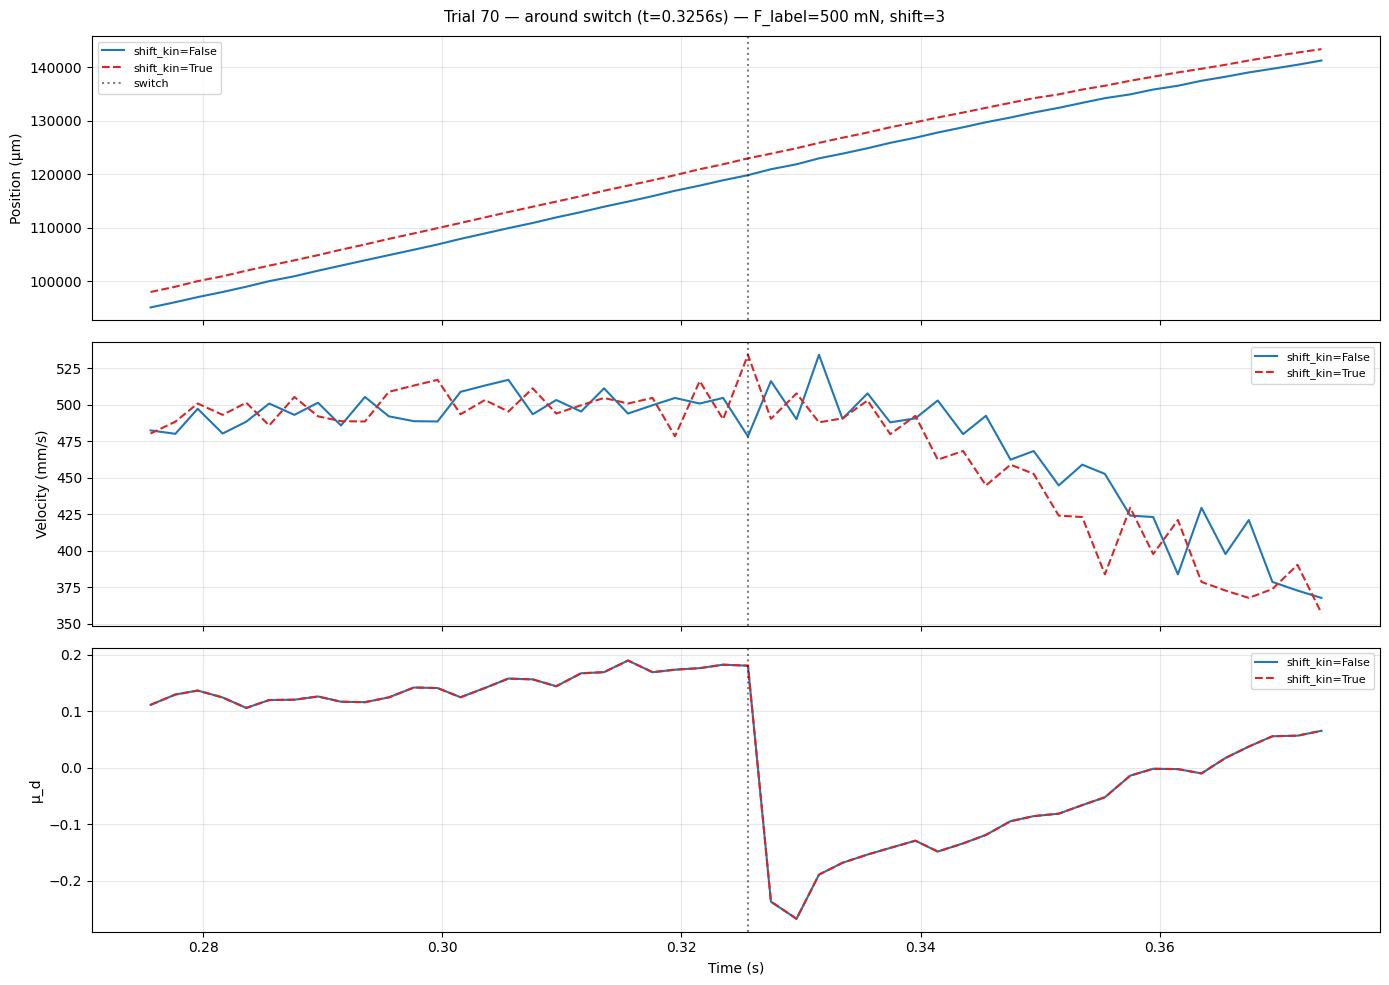

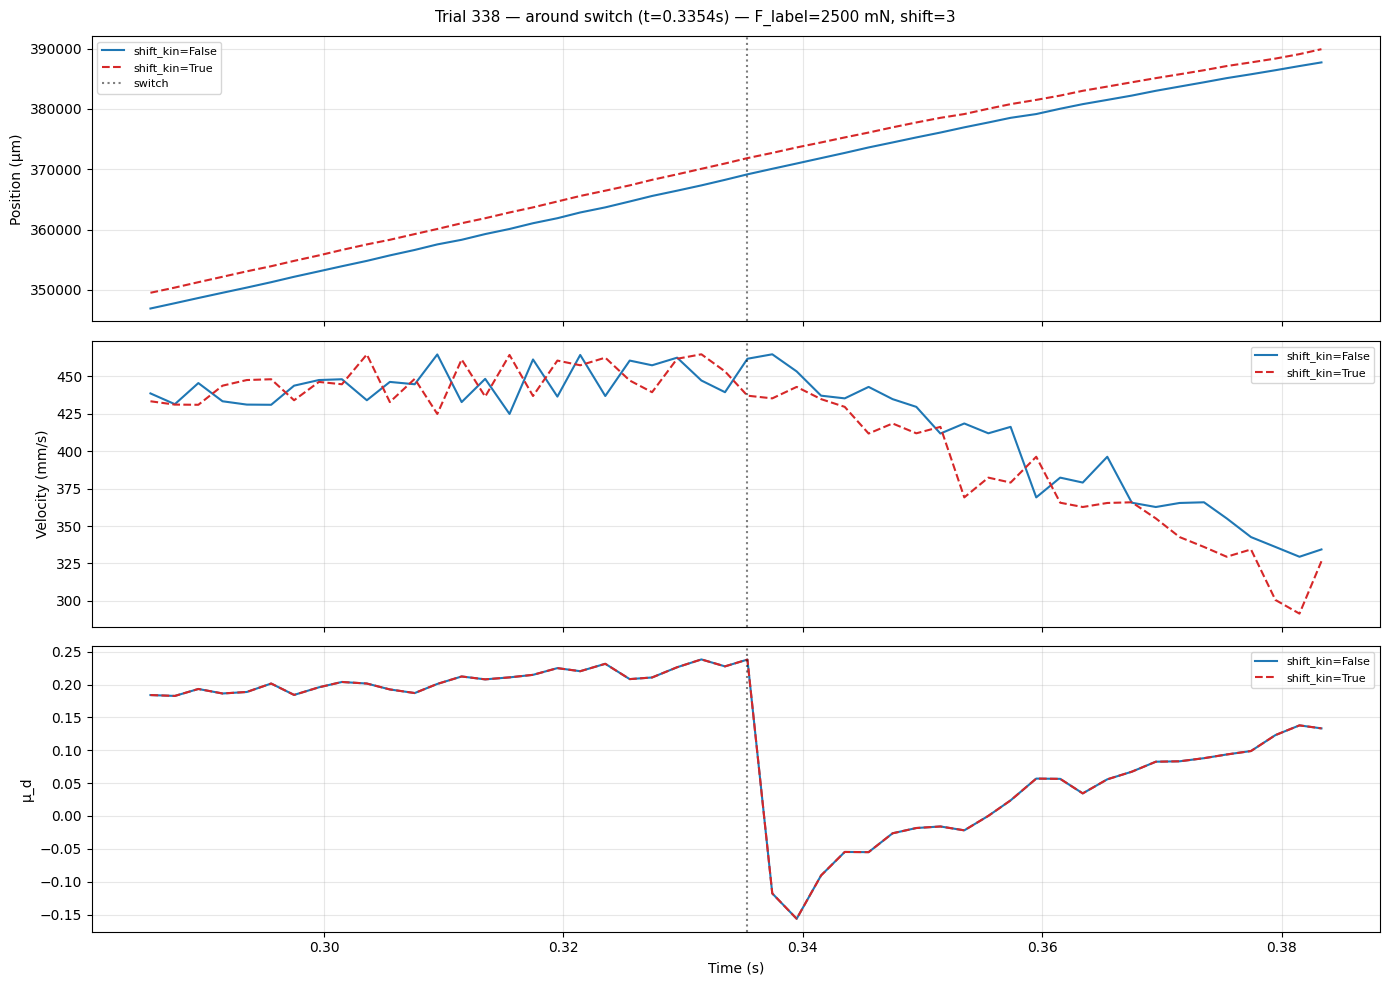

Trial 342: no switch detected, skipping


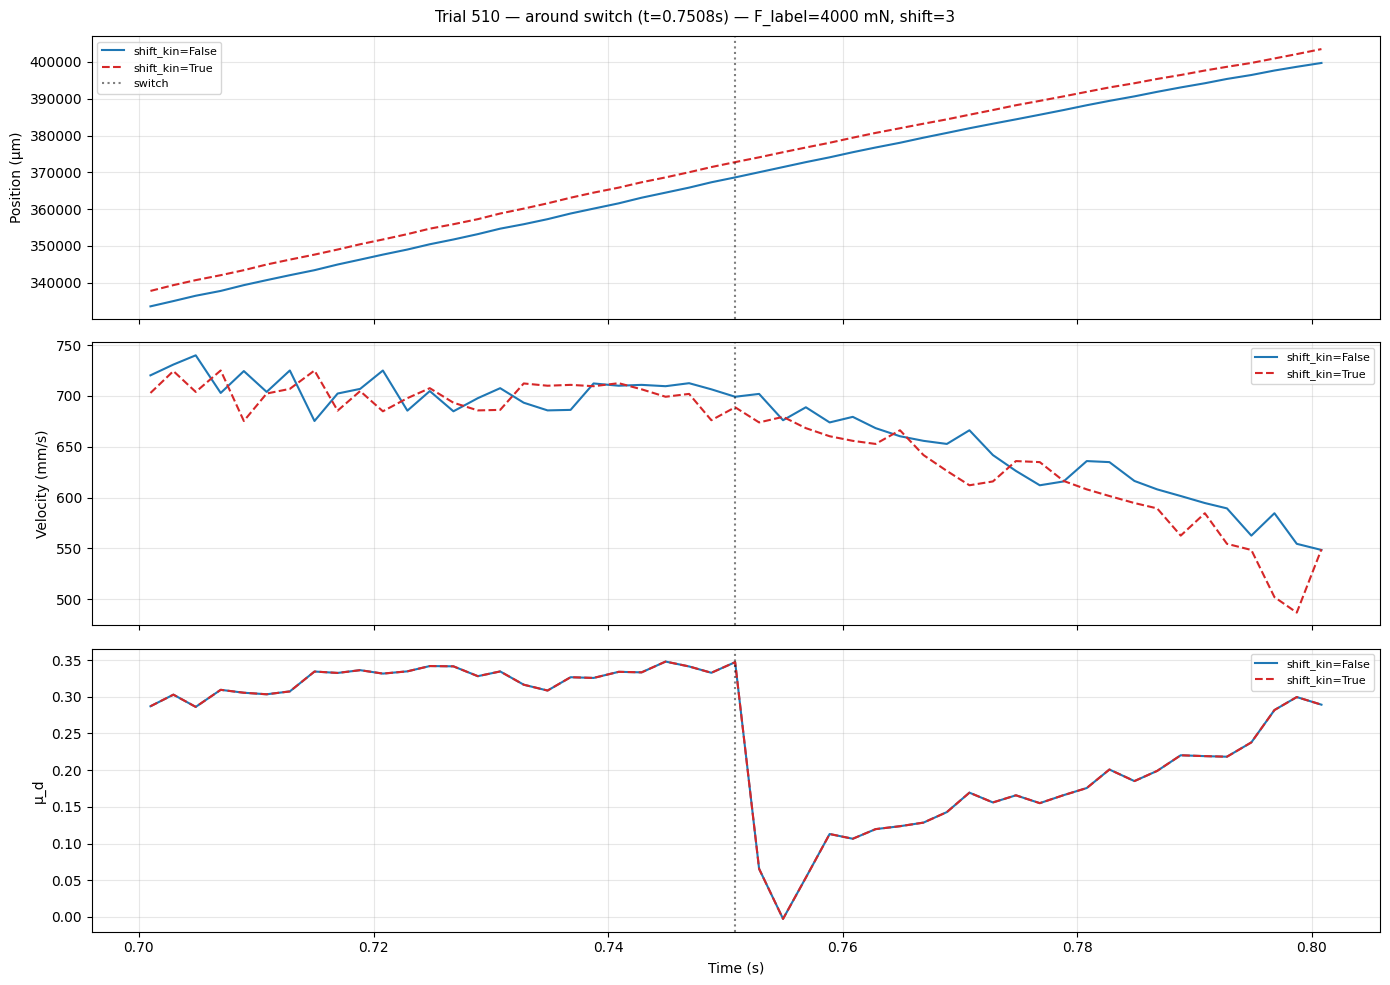

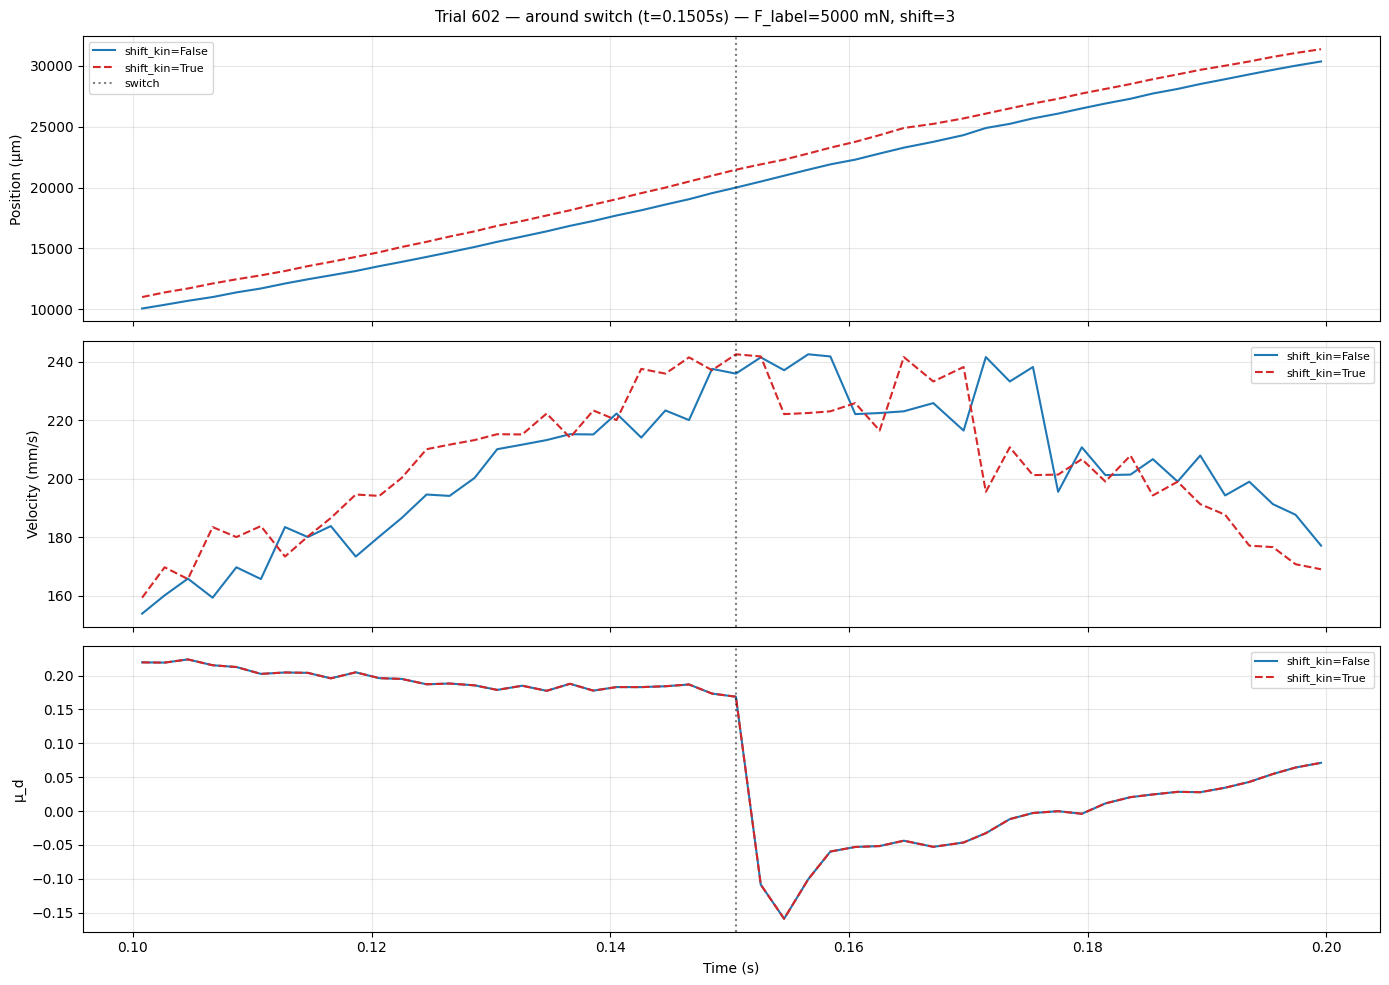

In [17]:
def find_switch_time(rec):
    """Find the time index where force_commanded changes value (the rampdown switch)."""
    fc = rec["force_commanded_mN"]
    diffs = np.diff(fc)
    change_idxs = np.where(np.abs(diffs) > 1.0)[0]
    if len(change_idxs) == 0:
        return None
    return change_idxs[0]

# Pick 5 random trials for the comparison
rng = np.random.default_rng(seed=42)
trial_nums_noshift = {r["trial_num"]: r for r in friction_noshift}
trial_nums_shifted = {r["trial_num"]: r for r in friction_shifted}
common_trials = sorted(set(trial_nums_noshift) & set(trial_nums_shifted))
chosen = rng.choice(common_trials, size=min(5, len(common_trials)), replace=False)

WINDOW_S = 0.05  # seconds of context around switch point

for tn in sorted(chosen):
    rec_ns = trial_nums_noshift[tn]
    rec_sh = trial_nums_shifted[tn]

    switch_idx = find_switch_time(rec_ns)
    if switch_idx is None:
        print(f"Trial {tn}: no switch detected, skipping")
        continue

    t_switch = rec_ns["t_stream_s"][switch_idx]
    t_lo = t_switch - WINDOW_S
    t_hi = t_switch + WINDOW_S

    mask_ns = (rec_ns["t_stream_s"] >= t_lo) & (rec_ns["t_stream_s"] <= t_hi)
    mask_sh = (rec_sh["t_stream_s"] >= t_lo) & (rec_sh["t_stream_s"] <= t_hi)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Position
    ax = axes[0]
    ax.plot(rec_ns["t_stream_s"][mask_ns], rec_ns["position_um"][mask_ns],
            linewidth=1.5, color="tab:blue", label="shift_kin=False")
    ax.plot(rec_sh["t_stream_s"][mask_sh], rec_sh["position_um"][mask_sh],
            linewidth=1.5, color="tab:red", linestyle="--", label="shift_kin=True")
    ax.axvline(t_switch, color="k", linestyle=":", alpha=0.5, label="switch")
    ax.set_ylabel("Position (µm)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Velocity
    ax = axes[1]
    ax.plot(rec_ns["t_stream_s"][mask_ns], rec_ns["velocity_mm_s"][mask_ns],
            linewidth=1.5, color="tab:blue", label="shift_kin=False")
    ax.plot(rec_sh["t_stream_s"][mask_sh], rec_sh["velocity_mm_s"][mask_sh],
            linewidth=1.5, color="tab:red", linestyle="--", label="shift_kin=True")
    ax.axvline(t_switch, color="k", linestyle=":", alpha=0.5)
    ax.set_ylabel("Velocity (mm/s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # mu_d
    ax = axes[2]
    ax.plot(rec_ns["t_stream_s"][mask_ns], rec_ns["mu_d"][mask_ns],
            linewidth=1.5, color="tab:blue", label="shift_kin=False")
    ax.plot(rec_sh["t_stream_s"][mask_sh], rec_sh["mu_d"][mask_sh],
            linewidth=1.5, color="tab:red", linestyle="--", label="shift_kin=True")
    ax.axvline(t_switch, color="k", linestyle=":", alpha=0.5)
    ax.set_ylabel("μ_d")
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.suptitle(f"Trial {tn} — around switch (t={t_switch:.4f}s) — "
                 f"F_label={rec_ns['force_label_mN']} mN, shift={STREAM_FORCE_SHIFT}",
                 fontsize=11)
    plt.tight_layout()
    plt.show()

## Quantifying the error: unshifted vs aligned position/velocity

With `shift=3`, the friction coefficient `mu_d` is identical in both cases — only position and velocity differ. For sample index `i` in the trimmed arrays:
- **Unshifted** (`shift_kinematics=False`): `pos[i]`, `vel[i]`
- **Aligned** (`shift_kinematics=True`): `pos[i+3]`, `vel[i+3]`

The question: how much do these input features differ, and does it matter for training a network that maps `(position, velocity) → mu_d`?

In [20]:
# ---------------------------------------------------------------------------
# Compute per-sample differences between unshifted and aligned pos/vel
# ---------------------------------------------------------------------------
delta_pos_all = []      # pos_aligned - pos_unshifted  (µm)
delta_vel_all = []      # vel_aligned - vel_unshifted  (mm/s)
pos_unshifted_all = []
vel_unshifted_all = []
pos_aligned_all = []
vel_aligned_all = []
mu_d_all = []
force_aligned_all = []
accel_aligned_all = []

for rec_ns, rec_sh in zip(friction_noshift, friction_shifted):
    assert rec_ns["trial_num"] == rec_sh["trial_num"]
    # mu_d should be identical
    assert np.allclose(rec_ns["mu_d"], rec_sh["mu_d"], atol=1e-12), \
        f"Trial {rec_ns['trial_num']}: mu_d mismatch!"

    mask = rec_ns["t_stream_s"] >= T_IGNORE_S

    dp = rec_sh["position_um"][mask] - rec_ns["position_um"][mask]
    dv = rec_sh["velocity_mm_s"][mask] - rec_ns["velocity_mm_s"][mask]

    delta_pos_all.append(dp)
    delta_vel_all.append(dv)
    pos_unshifted_all.append(rec_ns["position_um"][mask])
    vel_unshifted_all.append(rec_ns["velocity_mm_s"][mask])
    pos_aligned_all.append(rec_sh["position_um"][mask])
    vel_aligned_all.append(rec_sh["velocity_mm_s"][mask])
    mu_d_all.append(rec_ns["mu_d"][mask])
    force_aligned_all.append(rec_ns["force_mN"][mask])
    accel_aligned_all.append(rec_ns["accel_mmpss"][mask])

delta_pos = np.concatenate(delta_pos_all)
delta_vel = np.concatenate(delta_vel_all)
pos_unshifted = np.concatenate(pos_unshifted_all)
vel_unshifted = np.concatenate(vel_unshifted_all)
pos_aligned = np.concatenate(pos_aligned_all)
vel_aligned = np.concatenate(vel_aligned_all)
mu_d_flat = np.concatenate(mu_d_all)
force_flat = np.concatenate(force_aligned_all)
accel_flat = np.concatenate(accel_aligned_all)

print(f"Total samples (t >= {T_IGNORE_S}s): {len(delta_pos)}")
print(f"\n{'='*65}")
print("POSITION DIFFERENCE (aligned - unshifted) in µm")
print(f"{'='*65}")
print(f"  Mean:   {np.mean(delta_pos):+.2f} µm")
print(f"  Median: {np.median(delta_pos):+.2f} µm")
print(f"  Std:    {np.std(delta_pos):.2f} µm")
print(f"  |Δpos| mean:   {np.mean(np.abs(delta_pos)):.2f} µm")
print(f"  |Δpos| median: {np.median(np.abs(delta_pos)):.2f} µm")
print(f"  |Δpos| 95th %%: {np.percentile(np.abs(delta_pos), 95):.2f} µm")
print(f"  |Δpos| max:    {np.max(np.abs(delta_pos)):.2f} µm")

pos_range = np.ptp(pos_unshifted)
print(f"\n  Position range (unshifted): {np.min(pos_unshifted):.0f} – {np.max(pos_unshifted):.0f} µm  (span: {pos_range:.0f} µm)")
print(f"  |Δpos| mean / pos_range:  {np.mean(np.abs(delta_pos)) / pos_range * 100:.4f}%")

print(f"\n{'='*65}")
print("VELOCITY DIFFERENCE (aligned - unshifted) in mm/s")
print(f"{'='*65}")
print(f"  Mean:   {np.mean(delta_vel):+.4f} mm/s")
print(f"  Median: {np.median(delta_vel):+.4f} mm/s")
print(f"  Std:    {np.std(delta_vel):.4f} mm/s")
print(f"  |Δvel| mean:   {np.mean(np.abs(delta_vel)):.4f} mm/s")
print(f"  |Δvel| median: {np.median(np.abs(delta_vel)):.4f} mm/s")
print(f"  |Δvel| 95th %%: {np.percentile(np.abs(delta_vel), 95):.4f} mm/s")
print(f"  |Δvel| max:    {np.max(np.abs(delta_vel)):.4f} mm/s")

vel_range = np.ptp(vel_unshifted)
print(f"\n  Velocity range (unshifted): {np.min(vel_unshifted):.2f} – {np.max(vel_unshifted):.2f} mm/s  (span: {vel_range:.2f} mm/s)")
print(f"  |Δvel| mean / vel_range:  {np.mean(np.abs(delta_vel)) / vel_range * 100:.4f}%")

# Relative errors (only where |value| > small threshold to avoid div-by-zero)
pos_thresh = 100.0  # µm
vel_thresh = 0.5    # mm/s
pos_mask = np.abs(pos_unshifted) > pos_thresh
vel_mask = np.abs(vel_unshifted) > vel_thresh

if np.any(pos_mask):
    rel_pos = np.abs(delta_pos[pos_mask]) / np.abs(pos_unshifted[pos_mask]) * 100
    print(f"\n  Relative position error (|pos| > {pos_thresh} µm, {np.sum(pos_mask)} samples):")
    print(f"    Mean: {np.mean(rel_pos):.4f}%   Median: {np.median(rel_pos):.4f}%   95th: {np.percentile(rel_pos, 95):.4f}%")

if np.any(vel_mask):
    rel_vel = np.abs(delta_vel[vel_mask]) / np.abs(vel_unshifted[vel_mask]) * 100
    print(f"\n  Relative velocity error (|vel| > {vel_thresh} mm/s, {np.sum(vel_mask)} samples):")
    print(f"    Mean: {np.mean(rel_vel):.4f}%   Median: {np.median(rel_vel):.4f}%   95th: {np.percentile(rel_vel, 95):.4f}%")

Total samples (t >= 0.015s): 248087

POSITION DIFFERENCE (aligned - unshifted) in µm
  Mean:   +2126.95 µm
  Median: +2156.00 µm
  Std:    1378.95 µm
  |Δpos| mean:   2127.01 µm
  |Δpos| median: 2156.00 µm
  |Δpos| 95th %%: 4182.00 µm
  |Δpos| max:    41017.00 µm

  Position range (unshifted): 1660 – 519850 µm  (span: 518190 µm)
  |Δpos| mean / pos_range:  0.4105%

VELOCITY DIFFERENCE (aligned - unshifted) in mm/s
  Mean:   -0.0483 mm/s
  Median: -0.1539 mm/s
  Std:    48.1199 mm/s
  |Δvel| mean:   16.7377 mm/s
  |Δvel| median: 12.2235 mm/s
  |Δvel| 95th %%: 45.1302 mm/s
  |Δvel| max:    5951.8741 mm/s

  Velocity range (unshifted): -3.87 – 6388.90 mm/s  (span: 6392.77 mm/s)
  |Δvel| mean / vel_range:  0.2618%

  Relative position error (|pos| > 100.0 µm, 248087 samples):
    Mean: 1.9814%   Median: 1.1445%   95th: 7.5247%

  Relative velocity error (|vel| > 0.5 mm/s, 247340 samples):
    Mean: 8.7950%   Median: 4.6906%   95th: 26.4520%


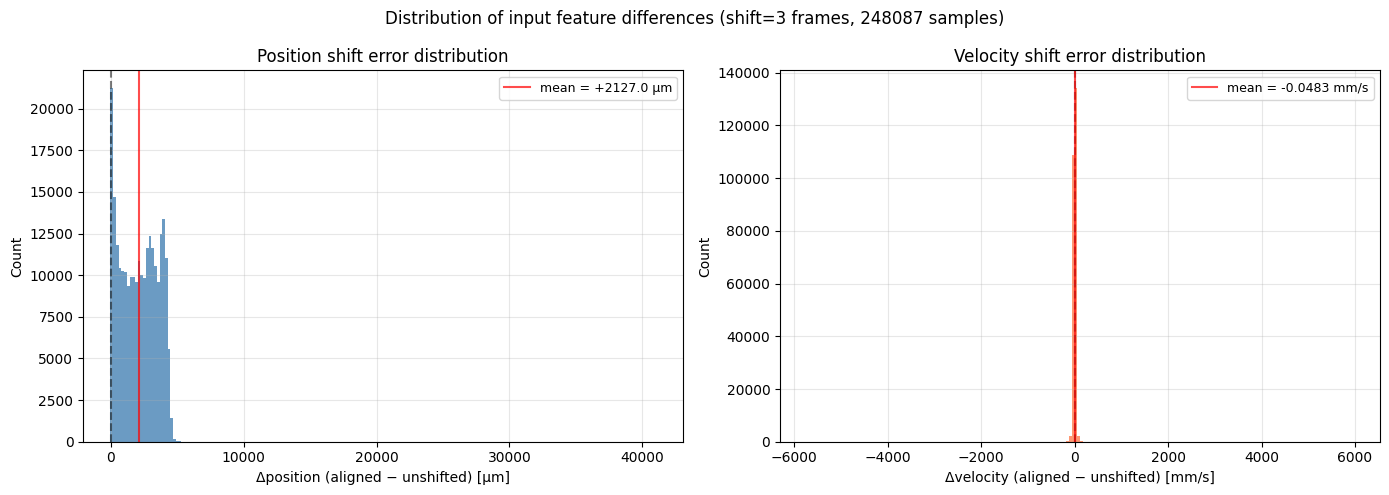

In [21]:
# ---------------------------------------------------------------------------
# Histograms of Δposition and Δvelocity
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(delta_pos, bins=200, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(0, color="k", linestyle="--", alpha=0.5)
ax.axvline(np.mean(delta_pos), color="red", linestyle="-", alpha=0.7,
           label=f"mean = {np.mean(delta_pos):+.1f} µm")
ax.set_xlabel("Δposition (aligned − unshifted) [µm]")
ax.set_ylabel("Count")
ax.set_title("Position shift error distribution")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(delta_vel, bins=200, color="coral", edgecolor="none", alpha=0.8)
ax.axvline(0, color="k", linestyle="--", alpha=0.5)
ax.axvline(np.mean(delta_vel), color="red", linestyle="-", alpha=0.7,
           label=f"mean = {np.mean(delta_vel):+.4f} mm/s")
ax.set_xlabel("Δvelocity (aligned − unshifted) [mm/s]")
ax.set_ylabel("Count")
ax.set_title("Velocity shift error distribution")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f"Distribution of input feature differences (shift={STREAM_FORCE_SHIFT} frames, "
             f"{len(delta_pos)} samples)", fontsize=12)
plt.tight_layout()
plt.show()

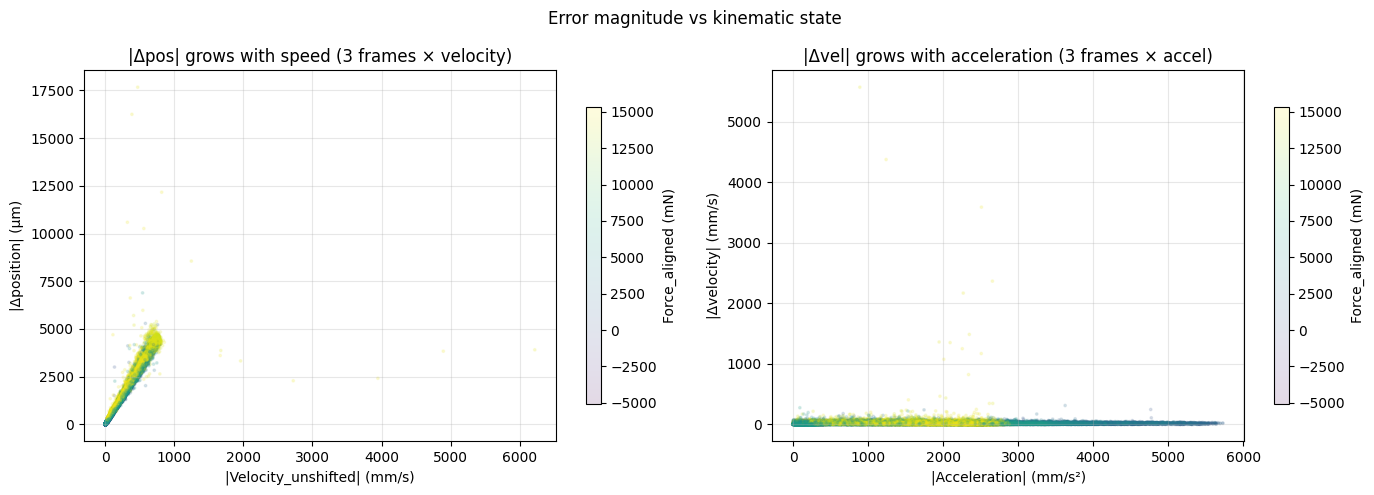

In [22]:
# ---------------------------------------------------------------------------
# |Δpos| and |Δvel| as a function of velocity magnitude
# (higher speeds = more position change per frame = larger Δpos)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subsample for plotting speed (every 10th point)
step = max(1, len(delta_pos) // 50000)
idx = np.arange(0, len(delta_pos), step)

ax = axes[0]
sc = ax.scatter(np.abs(vel_unshifted[idx]), np.abs(delta_pos[idx]),
                s=3, alpha=0.15, c=force_flat[idx], cmap="viridis")
ax.set_xlabel("|Velocity_unshifted| (mm/s)")
ax.set_ylabel("|Δposition| (µm)")
ax.set_title("|Δpos| grows with speed (3 frames × velocity)")
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="Force_aligned (mN)", shrink=0.8)

ax = axes[1]
sc = ax.scatter(np.abs(accel_flat[idx]), np.abs(delta_vel[idx]),
                s=3, alpha=0.15, c=force_flat[idx], cmap="viridis")
ax.set_xlabel("|Acceleration| (mm/s²)")
ax.set_ylabel("|Δvelocity| (mm/s)")
ax.set_title("|Δvel| grows with acceleration (3 frames × accel)")
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="Force_aligned (mN)", shrink=0.8)

plt.suptitle("Error magnitude vs kinematic state", fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/_z/v3g3vzrx0j752hbq549k0xnm0000gn/T/ipykernel_12353/2085768058.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


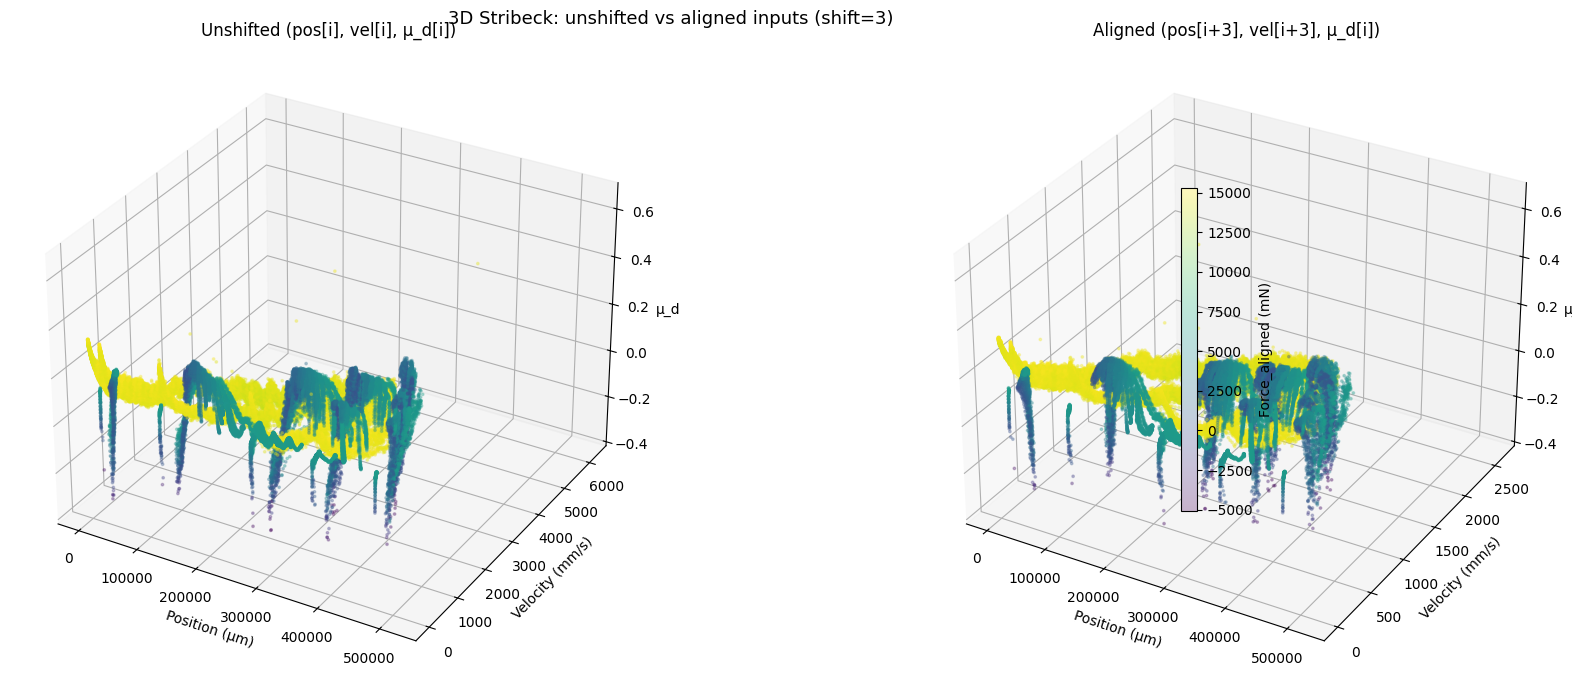

In [23]:
# ---------------------------------------------------------------------------
# Side-by-side 3D Stribeck: unshifted vs aligned inputs, same mu_d
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 7))

ax1 = fig.add_subplot(121, projection="3d")
sc1 = ax1.scatter(pos_unshifted[idx], vel_unshifted[idx], mu_d_flat[idx],
                  s=3, alpha=0.3, c=force_flat[idx], cmap="viridis")
ax1.set_xlabel("Position (µm)")
ax1.set_ylabel("Velocity (mm/s)")
ax1.set_zlabel("μ_d")
ax1.set_title("Unshifted (pos[i], vel[i], μ_d[i])")

ax2 = fig.add_subplot(122, projection="3d")
sc2 = ax2.scatter(pos_aligned[idx], vel_aligned[idx], mu_d_flat[idx],
                  s=3, alpha=0.3, c=force_flat[idx], cmap="viridis")
ax2.set_xlabel("Position (µm)")
ax2.set_ylabel("Velocity (mm/s)")
ax2.set_zlabel("μ_d")
ax2.set_title("Aligned (pos[i+3], vel[i+3], μ_d[i])")

fig.colorbar(sc2, ax=[ax1, ax2], label="Force_aligned (mN)", shrink=0.6, pad=0.1)
plt.suptitle(f"3D Stribeck: unshifted vs aligned inputs (shift={STREAM_FORCE_SHIFT})", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
# ---------------------------------------------------------------------------
# Per-force-level breakdown: how does the error scale with commanded force?
# (Higher force → higher velocity → larger Δpos per 3 frames)
# ---------------------------------------------------------------------------
print(f"{'Force (mN)':>12s} | {'|Δpos| mean':>12s} | {'|Δpos| 95th':>12s} | "
      f"{'|Δvel| mean':>12s} | {'|Δvel| 95th':>12s} | {'N samples':>10s}")
print("-" * 85)

for fl in force_levels:
    recs_ns = [r for r in friction_noshift if r["force_label_mN"] == fl]
    recs_sh = [r for r in friction_shifted if r["force_label_mN"] == fl]
    if not recs_ns:
        continue

    dp_level = []
    dv_level = []
    for rns, rsh in zip(recs_ns, recs_sh):
        mask = rns["t_stream_s"] >= T_IGNORE_S
        dp_level.append(rsh["position_um"][mask] - rns["position_um"][mask])
        dv_level.append(rsh["velocity_mm_s"][mask] - rns["velocity_mm_s"][mask])

    dp_level = np.concatenate(dp_level)
    dv_level = np.concatenate(dv_level)

    print(f"{fl:12d} | {np.mean(np.abs(dp_level)):12.2f} | {np.percentile(np.abs(dp_level), 95):12.2f} | "
          f"{np.mean(np.abs(dv_level)):12.4f} | {np.percentile(np.abs(dv_level), 95):12.4f} | {len(dp_level):10d}")

  Force (mN) |  |Δpos| mean |  |Δpos| 95th |  |Δvel| mean |  |Δvel| 95th |  N samples
-------------------------------------------------------------------------------------
           0 |      2379.64 |      4286.00 |      18.3081 |      47.1661 |      16341
         500 |      2331.03 |      4176.15 |      17.6754 |      44.6787 |      16498
        1000 |      2331.37 |      4153.00 |      19.7454 |      45.0300 |      16498
        1500 |      2291.55 |      4031.00 |      17.3168 |      44.5820 |      16620
        2000 |      2305.43 |      4063.00 |      20.4958 |      44.3480 |      16695
        2500 |      2271.12 |      4052.00 |      17.1334 |      44.2942 |      17106
        3000 |      2277.32 |      4187.00 |      16.7310 |      43.8414 |      17620
        3500 |      2227.04 |      4136.00 |      16.2980 |      43.6980 |      18072
        4000 |      2231.21 |      4158.00 |      16.8339 |      43.4948 |      18258
        4500 |      2194.66 |      4195.40 |      15.5

### Practical interpretation for network training

The key takeaway numbers from the above:

- **μ_d is identical** regardless of whether you use unshifted or aligned position/velocity — the friction coefficient depends only on `force_aligned` and `accel_aligned`, which are the same in both cases.
- **Δposition** ≈ `velocity × 3 × dt` — larger at higher speeds. If positions span ~250,000 µm and typical Δpos is small relative to that, the position input barely changes.
- **Δvelocity** ≈ `acceleration × 3 × dt` — larger during transients (rampdown switch). If velocity is slowly varying (steady-state sliding), Δvel is negligible.

**Bottom line for training**: If your future deployment will read position and velocity in real-time (no future lookahead), training with **unshifted** inputs is the more honest representation of what the network will see online.If the errors above are small relative to the range of each feature, then both training sets will produce similar networks — but unshifted is strictly more conservative and representative of real-time conditions.